=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


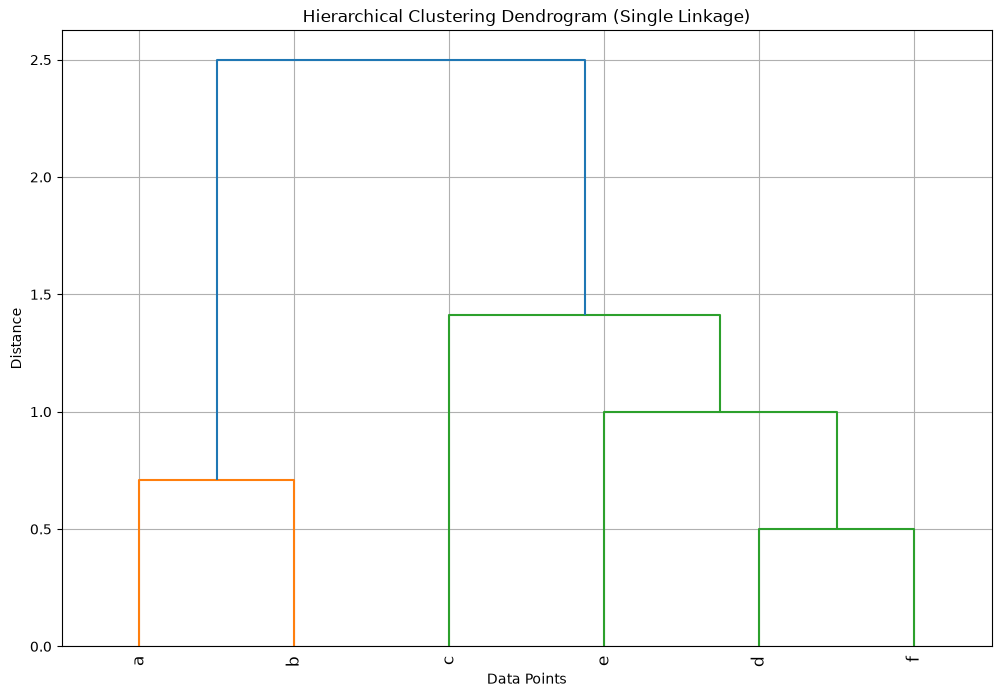

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

- numpy: membuat array data numerik.
- pandas: menampilkan distance matrix dalam bentuk tabel.
- linkage: menjalankan algoritma hierarchical clustering.
- dendrogram: menggambar pohon hasil clustering.
- pdist: menghitung jarak antar semua pasang titik.
- squareform: mengubah hasil pdist (bentuk vektor) jadi matriks persegi.
- matplotlib.pyplot: membuat plot.

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

Ada 6 titik dengan 2 fitur (koordinat x dan y). Tiap baris mewakili satu titik, diberi label a sampai f lewat komentar.

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
columns=['a','b','c','d','e','f'],
index=['a','b','c','d','e','f'])

pdist(..., metric='euclidean') menghitung jarak Euclidean semua pasangan titik. Hasilnya vektor 1 dimensi berisi 15 nilai (6×5/2).
squareform(...) mengubahnya jadi matriks 6×6 yang simetris dengan diagonal 0.
pd.DataFrame(...) memberi nama baris dan kolom a–f supaya mudah dibaca.

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

Mencetak tabel jarak. Contoh: jarak a–b = 0.707, d–f = 0.5 (paling kecil, jadi d dan f digabung pertama).

linked = linkage(data, method='single')

Menjalankan algoritma agglomerative: mulai dari tiap titik sebagai cluster sendiri, lalu terus menggabungkan dua cluster terdekat. method='single' berarti jarak antar cluster = jarak terdekat antar anggotanya. Hasilnya linked berupa matriks 5×4. Tiap barisnya berisi: indeks cluster 1, indeks cluster 2, jarak penggabungan, dan jumlah anggota cluster baru.

plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a','b','c','d','e','f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()
figsize=(12, 8): ukuran gambar.
dendrogram(linked, labels=..., leaf_rotation=90): menggambar pohon, label titik diputar 90° supaya tidak bertumpuk.
Sumbu Y adalah jarak saat penggabungan terjadi. Makin tinggi garisnya, makin jauh dua cluster itu sebelum digabung.
plt.grid(True) menampilkan garis bantu, plt.show() menampilkan plot.

In [5]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Membaca file CSV ke DataFrame df. df.head() menampilkan 5 baris pertama untuk mengecek isi data (kolom CustomerID, Genre, Age, Annual Income, Spending Score). Path /content/ menandakan kode ini dijalankan di Google Colab, jadi kalau kamu jalankan di komputer sendiri, sesuaikan path-nya.

In [6]:
x = df.iloc[:, [3, 4]].values

iloc[:, [3, 4]] mengambil semua baris dan hanya kolom indeks 3 dan 4, yaitu Annual Income dan Spending Score. .values mengubahnya jadi array NumPy. Fitur lain (ID, gender, umur) tidak dipakai.

In [7]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

StandardScaler mengubah tiap fitur jadi rata-rata 0 dan standar deviasi 1.
Ini penting karena clustering berbasis jarak. Income (15–137) dan Spending Score (1–99) skalanya berbeda, jadi tanpa scaling fitur yang rentangnya lebih besar akan mendominasi jarak.
fit_transform menghitung mean/std lalu langsung menerapkannya.
.shape menghasilkan (200, 2), artinya 200 pelanggan dengan 2 fitur.

In [8]:

from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

Menjalankan hierarchical clustering pada data yang sudah di-scale, memakai complete linkage (jarak antar cluster = jarak terjauh antar anggota) dan jarak Euclidean. Hasilnya disimpan di clustering.

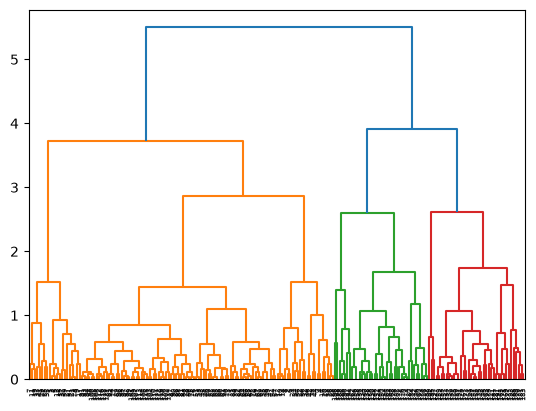

In [9]:

import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

Menggambar dendrogram untuk 200 pelanggan. Label sumbu X terlihat penuh sesak karena ada 200 titik. Warna oranye, hijau, dan merah adalah tiga cluster utama yang otomatis diberi warna berbeda oleh dendrogram (berdasarkan threshold default 70% dari tinggi maksimum).

Kalau mau, aku bisa buatkan versi lengkap dalam satu file notebook (.ipynb) atau laporan Word/PDF yang sudah berisi kode, penjelasan, dan analisis untuk dikumpulkan ke ecourse.

Tuga Praktikum W05S03

Nama: Fani Namesia R. Sianturi
Nim: 42324045

Tugas!!
Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage

Dataset terdiri dari enam titik (a, b, c, d, e, f). Berdasarkan distance matrix:

Titik a dan b saling berdekatan (jarak 0,707).
Titik d, e, f saling berdekatan (d–f = 0,5; d–e = 1,0).
Titik c agak terpisah, tetapi paling dekat dengan e (1,414).

Jadi secara alami data terbagi menjadi dua kelompok besar, yaitu {a, b} dan {c, d, e, f}.

Ketiga metode linkage menggunakan data dan distance matrix yang sama. Perbedaannya hanya pada cara menghitung jarak antar cluster:

- Metode	Cara menghitung jarak antar cluster
- Single linkage	Jarak terdekat antara dua anggota dari cluster yang berbeda
- Complete linkage	Jarak terjauh antara dua anggota dari cluster yang berbeda
- Average linkage	Rata-rata jarak dari seluruh pasangan anggota kedua cluster

. Perbandingan plot

Persamaan

Bentuk pohon sama. Urutan penggabungan identik di ketiga plot: (d,f) → (a,b) → e → c → penggabungan akhir dua kelompok besar.
Urutan label di sumbu X sama: a, b, c, e, d, f.
Dua penggabungan pertama setinggi sama (0,5 dan 0,707), karena yang digabung masih titik tunggal sehingga jarak terdekat, terjauh, dan rata-rata bernilai sama.

Perbedaan

Single linkage: garis penggabungan paling rendah; sumbu Y hanya sampai 2,5. Garis penggabungan antar tingkat berdekatan, sehingga dendrogram tampak "landai". Cluster dapat terbentuk berantai (chaining): c bergabung di 1,414 hanya karena dekat dengan e, dan kelompok akhir bergabung di 2,5 karena pasangan terdekat b–f.
Complete linkage: garis penggabungan paling tinggi; sumbu Y sampai 5,657 (jarak a–c, pasangan terjauh). Penggabungan terakhir melonjak jauh dari penggabungan sebelumnya (2,5 → 5,657), sehingga pemisahan {a,b} dan {c,d,e,f} tampak paling tegas dan cluster cenderung kompak.
Average linkage: tinggi penggabungan berada di antara keduanya; sumbu Y sampai 3,826. Hasilnya lebih seimbang karena tidak ditentukan oleh satu pasangan titik terdekat atau terjauh saja.

Urutan tinggi penggabungan: single ≤ average ≤ complete.

